# 🔬 PatchTST Conformer — Entraînement Mixte .npy + CSV
## Modèle robuste aux deux domaines : synthétique (filtre membrane) + réel (bruit instrument)
### CMKL University · Stage 2026

---

**Constat qui motive ce notebook** : le modèle Conformer entraîné uniquement sur
les données `.npy` (95.25% sur test officiel) chute à **23.47%** sur les vrais
spectres CSV bruités — domain gap massif. L'interférence de filtre membrane
(.npy) n'est pas comparable au bruit instrument réel (CSV).

**Solution** : entraîner sur un **mélange des deux sources** pour que le backbone
apprenne des représentations chimiques robustes à plusieurs types de bruit,
pas seulement à l'interférence filtre membrane.

**Architecture** : identique au meilleur run .npy — Conformer + Attention Pooling
+ Block Masking, P=320/S=256, n_layers=5, d_model=256, n_heads=16, beta=0.5

**Évaluation** : sur **deux test sets séparés** (.npy officiel ET CSV réel)
pour vérifier que le modèle progresse sur les deux domaines simultanément.


---
## ⚙️ Section 0 — Installation, Imports & Configuration


In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['scikit-learn', 'seaborn']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        install(pkg)

print('✓ Packages prêts')

✓ Packages prêts


In [2]:
import os, glob, re, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HOME   = os.path.expanduser('~')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'HOME   : {HOME}')

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
HOME   : /home/glider


In [3]:
from torch.utils.tensorboard import SummaryWriter

LOG_DIR = os.path.join(HOME, 'runs', 'patchtst_mixed')
os.makedirs(LOG_DIR, exist_ok=True)
writer  = SummaryWriter(LOG_DIR)
print(f'✓ TensorBoard writer → {LOG_DIR}')
print(f'  Terminal : tensorboard --logdir {LOG_DIR} --port 6006')

def safe_log(writer, *args, method='add_scalar', **kwargs):
    try:
        getattr(writer, method)(*args, **kwargs)
    except Exception:
        pass

CONFUSION_PAIRS = [
    ('LDPE', 'HDPE'), ('PVA', 'CELLULOSE'), ('PVA', 'CHITOSAN'),
    ('PET', 'PLA'), ('PET', 'PBAT'), ('PVC', 'PVDF'), ('CELLULOSE', 'CHITOSAN'),
]

✓ TensorBoard writer → /home/glider/runs/patchtst_mixed
  Terminal : tensorboard --logdir /home/glider/runs/patchtst_mixed --port 6006


In [4]:
# ════════════════════════════════════════════════════════════════════
# CONFIG — config optimale confirmée sur .npy
# ════════════════════════════════════════════════════════════════════
CFG = {
    'L'         : 6700,
    'WN_MIN'    : 650,
    'WN_MAX'    : 4000,
    'WN_STEP'   : 0.5,

    'patch_size' : 320,
    'stride'     : 256,

    'd_model'   : 256,
    'n_heads'   : 16,
    'n_layers'  : 5,
    'd_ff'      : 512,
    'dropout'   : 0.1,

    'mask_ratio'  : 0.40,
    'ssl_epochs'  : 100,
    'ssl_lr'      : 1e-3,
    'ssl_batch'   : 64,

    'alpha'        : 1.0,
    'beta'         : 0.5,
    'probe_epochs' : 80,
    'probe_lr'     : 1e-3,
    'ft_epochs'    : 80,
    'ft_lr'        : 1e-5,
    'batch_size'   : 32,

    'ssl_path'   : os.path.join(HOME, 'models', 'ssl_backbone_mixed.pth'),
    'probe_path' : os.path.join(HOME, 'models', 'probe_model_mixed.pth'),
    'final_path' : os.path.join(HOME, 'models', 'final_model_mixed.pth'),

    'noise_variant' : 'Upto30SNR',
}

os.makedirs(os.path.join(HOME, 'models'), exist_ok=True)

WN_GRID   = np.arange(CFG['WN_MIN'], CFG['WN_MAX'], CFG['WN_STEP'])
CFG['L']  = len(WN_GRID)
L = CFG['L']
N_PATCHES = (L - CFG['patch_size']) // CFG['stride'] + 2

print(f'L = {L} points')
print(f'N_PATCHES = {N_PATCHES}')
assert CFG['d_model'] % CFG['n_heads'] == 0
print('✓ Config validée')

L = 6700 points
N_PATCHES = 26
✓ Config validée


In [5]:
ASSUMED_CLASSES = [
    'ABS', 'ACRYLIC', 'CELLULOSE', 'CHITOSAN', 'ENR', 'EPDM', 'EVA', 'HDPE',
    'LDPE', 'NYLON', 'PBAT', 'PBS', 'PC', 'PEEK', 'PEI', 'PET',
    'PF THERMOPLASTIC', 'PF THERMOSET', 'PHB', 'PLA', 'PMMA', 'POM', 'PP',
    'PS', 'PTFE', 'PU', 'PVA', 'PVC', 'PVDF', 'SAN',
]
N_CLASSES = len(ASSUMED_CLASSES)
CFG['N_CLASSES'] = N_CLASSES

le = LabelEncoder()
le.fit(ASSUMED_CLASSES)
print(f'{N_CLASSES} classes (ordre alphabétique confirmé)')

30 classes (ordre alphabétique confirmé)


---
## 📊 Section 1 — Chargement des données .npy (source synthétique)


In [6]:
# ── Chemins .npy (à adapter selon ton organisation) ────────────────────────
NPY_ROOT  = os.path.join(HOME, 'data', '2026-FTIR-Preprocesed','2026 - FTIR - 4. Selected Datasets - Preprocessed')
TRAIN_DIR = os.path.join(NPY_ROOT, '1.1 TrainingSet - UptoY dB')
TEST_DIR  = os.path.join(NPY_ROOT, '1.2 TestSet - UptoY dB')

def npy_path(base_dir, filename):
    p = os.path.join(base_dir, filename)
    if not os.path.exists(p):
        print(f'  ✗ INTROUVABLE : {p}')
    return p

noise = CFG['noise_variant']
print(f'Niveau de bruit .npy sélectionné : {noise}')

npy_train_clean = np.load(npy_path(TRAIN_DIR, 'TrainGroundTruthSet_Pre.npy'))
npy_train_noisy = np.load(npy_path(TRAIN_DIR, f'TrainNoisySet_{noise}_Pre.npy'))
npy_test_clean  = np.load(npy_path(TEST_DIR,  'TestGroundTruthSet_Pre.npy'))
npy_test_noisy  = np.load(npy_path(TEST_DIR,  f'TestNoisySet_{noise}_Pre.npy'))

assert npy_train_clean.shape[1] == L

N_PER_CLASS_NPY_TRAIN = npy_train_clean.shape[0] // N_CLASSES
N_PER_CLASS_NPY_TEST  = npy_test_clean.shape[0]  // N_CLASSES

npy_labels_train = np.repeat(np.arange(N_CLASSES), N_PER_CLASS_NPY_TRAIN)
npy_labels_test  = np.repeat(np.arange(N_CLASSES), N_PER_CLASS_NPY_TEST)

print(f'\n✓ .npy Train : {npy_train_noisy.shape[0]} spectres ({N_PER_CLASS_NPY_TRAIN}/classe)')
print(f'✓ .npy Test  : {npy_test_noisy.shape[0]} spectres ({N_PER_CLASS_NPY_TEST}/classe)')

Niveau de bruit .npy sélectionné : Upto30SNR

✓ .npy Train : 18000 spectres (600/classe)
✓ .npy Test  : 18000 spectres (600/classe)


---
## 📁 Section 2 — Chargement des données CSV (source réelle)

Charge à la fois les spectres **propres (RM)** et **bruités (SD/noisy)** —
les propres serviront à construire les cibles de denoising proxy par classe,
exactement comme dans le notebook `PatchTST_MultiTask_CSV`.


In [7]:
CSV_ROOT = os.path.join(HOME, 'data', '2026-FirstDataSet', '2026 - Complete FTIR Dataset')

PATHS_CSV = {
    '2023_base' : os.path.join(CSV_ROOT, '2023 Dataset - 22 MP Types with 10 Clean and 60 Noisy'),
    '2025_ext'  : os.path.join(CSV_ROOT, '2025 Dataset 1 - Same 22 MP Types - Add 40 Spectra'),
    '2025_new'  : os.path.join(CSV_ROOT, '2025 Dataset 2 - New 9 MP Types - 50 Clean and 100 Noisy'),
}

for name, path in PATHS_CSV.items():
    status = '✓' if os.path.exists(path) else '✗ INTROUVABLE'
    n = len(glob.glob(os.path.join(path, '**/*.csv'), recursive=True)) if os.path.exists(path) else 0
    print(f'  {status}  {name:12s}  {n} fichiers CSV')

  ✓  2023_base     65 fichiers CSV
  ✓  2025_ext      23 fichiers CSV
  ✓  2025_new      17 fichiers CSV


In [8]:
EXCLUDE_FILES = {'ref.csv', 'reference.csv', 'background.csv', 'bg.csv'}

def is_noisy_csv(filepath):
    p = str(filepath).lower()
    if any(k in p for k in ['noisy', '_sd', '-sd', 'sd_']): return True
    if any(k in p for k in ['clean', '_rm', '-rm', 'rm_']): return False
    return False


def extract_label_csv(filepath):
    """Extrait le label et l'aligne avec ASSUMED_CLASSES."""
    name = Path(filepath).stem.upper()
    for pattern in ['_SD_', '_RM_', '_NOISY', '_CLEAN', 'PARTICLE', '-NOISY',
                    '-CLEAN', '_50', '_60', '_40', '_100', '_10', '_30',
                    ' SPECTRUMS', ' SPECTUMS', 'ADD_40', '-ADD_40']:
        name = name.replace(pattern, ' ')
    name = re.sub(r'\d+', '', name)
    name = re.sub(r'\bNEW\b|\bJAN\b|\bX\b', '', name)
    name = ' '.join(name.replace('_', ' ').replace('-', ' ').split())

    MAPPING = {
        'NYLON PARTICLE' : 'NYLON', 'PTEE' : 'PTFE', 'PTFE' : 'PTFE',
        'PF THERMOPLASTIC CLEAN' : 'PF THERMOPLASTIC',
        'PF THERMOSET CLEAN'     : 'PF THERMOSET',
    }
    if name in MAPPING: return MAPPING[name]
    if name in ASSUMED_CLASSES: return name
    for cls in ASSUMED_CLASSES:
        if cls in name or name in cls: return cls
    return None


def read_csv_multispectra(filepath, sep=','):
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
        start_idx = 0
        for i, line in enumerate(lines):
            parts = line.strip().split(sep)
            if len(parts) >= 2:
                try:
                    float(parts[0].replace(',', '.'))
                    start_idx = i; break
                except ValueError:
                    continue
        valid = ''.join(lines[start_idx:])
        headers = lines[start_idx-1].strip().split(sep) if start_idx > 0 else []
        try:
            df = pd.read_csv(io.StringIO(valid), sep=sep, header=None, decimal=',')
        except Exception:
            df = pd.read_csv(io.StringIO(valid), sep=sep, header=None, decimal='.')

        cols = []
        for ci, cn in enumerate(df.columns):
            h = headers[ci].upper() if ci < len(headers) else ''
            v = str(df[cn].iloc[0]).upper()
            if any(k in h for k in ['AIR','BACKGROUND','BG']): continue
            if any(k in v for k in ['AIR','BACKGROUND','BG']): continue
            cols.append(cn)

        df = df[cols].apply(pd.to_numeric, errors='coerce')
        df = df.dropna(subset=[df.columns[0]])
        if len(df) < 100: return None

        wn    = df.iloc[:, 0].values.astype(float)
        order = np.argsort(wn); wn = wn[order]
        spectra = []
        for c in range(1, df.shape[1]):
            ab = df.iloc[order, c].values.astype(float)
            if np.isnan(ab).all() or ab.std() < 1e-10: continue
            nans = np.isnan(ab)
            if nans.any():
                ab[nans] = np.interp(np.where(nans)[0], np.where(~nans)[0], ab[~nans])
            spectra.append(ab.astype(np.float32))
        return (wn, spectra) if spectra else None
    except Exception:
        return None

print('✓ Fonctions de lecture CSV définies')

✓ Fonctions de lecture CSV définies


In [9]:
print('Chargement des CSV (propres + bruités)...')
csv_records = []
labels_skipped = Counter()

for src_name, folder in PATHS_CSV.items():
    if not os.path.exists(folder):
        print(f'  ✗ {src_name} introuvable'); continue

    files = glob.glob(os.path.join(folder, '**/*.csv'), recursive=True)
    n_ok, n_skip = 0, 0

    for fp in files:
        if Path(fp).name.lower() in EXCLUDE_FILES: continue

        label = extract_label_csv(fp)
        if label is None:
            labels_skipped[Path(fp).stem] += 1
            n_skip += 1
            continue

        result = read_csv_multispectra(fp)
        if result is None: n_skip += 1; continue

        wn, spectra_list = result
        noisy = is_noisy_csv(fp)

        for sp in spectra_list:
            sp_interp = np.interp(WN_GRID, wn, sp).astype(np.float32)
            csv_records.append({
                'label': label, 'source': src_name,
                'is_noisy': noisy, 'spectrum': sp_interp,
            })
            n_ok += 1

    print(f'  ✓ {src_name:12s} : {n_ok:4d} spectres, {n_skip} ignorés')

df_csv_all = pd.DataFrame(csv_records)
df_csv_all['label_enc'] = le.transform(df_csv_all['label'])

print(f'\n  Total CSV : {len(df_csv_all)} spectres')
print(f'    Propres (RM) : {(~df_csv_all.is_noisy).sum()}')
print(f'    Bruités (SD) : {df_csv_all.is_noisy.sum()}')
if labels_skipped:
    print(f'\n  ⚠️ Labels non reconnus (ignorés) : {sum(labels_skipped.values())} fichiers')

Chargement des CSV (propres + bruités)...
  ✓ 2023_base    : 1518 spectres, 1 ignorés
  ✓ 2025_ext     :  881 spectres, 1 ignorés
  ✓ 2025_new     : 1145 spectres, 0 ignorés

  Total CSV : 3544 spectres
    Propres (RM) : 881
    Bruités (SD) : 2663

  ⚠️ Labels non reconnus (ignorés) : 2 fichiers


---
## 📈 Section 3 — Comparatif des volumes de données

⚠️ **Point important** : le dataset CSV est BEAUCOUP plus petit que le .npy.
Ce déséquilibre sera géré via le sampler pondéré (Section 5).


══════════════════════════════════════════════════════════════════════
  COMPARATIF DES VOLUMES DE DONNÉES
══════════════════════════════════════════════════════════════════════
Source                    |    Total |    Train |     Test
----------------------------------------------------------------------
npy (synthétique)         |    36000 |    18000 |    18000
CSV bruité (réel)         |     2663 |        — |        —
CSV propre (réel)         |      881 |        — |        —
----------------------------------------------------------------------

  Ratio npy_train / CSV_noisy : 6.8x
  → Le dataset .npy est 7x plus grand que le CSV bruité
  → Un sampler pondéré est nécessaire pour équilibrer les deux sources
══════════════════════════════════════════════════════════════════════


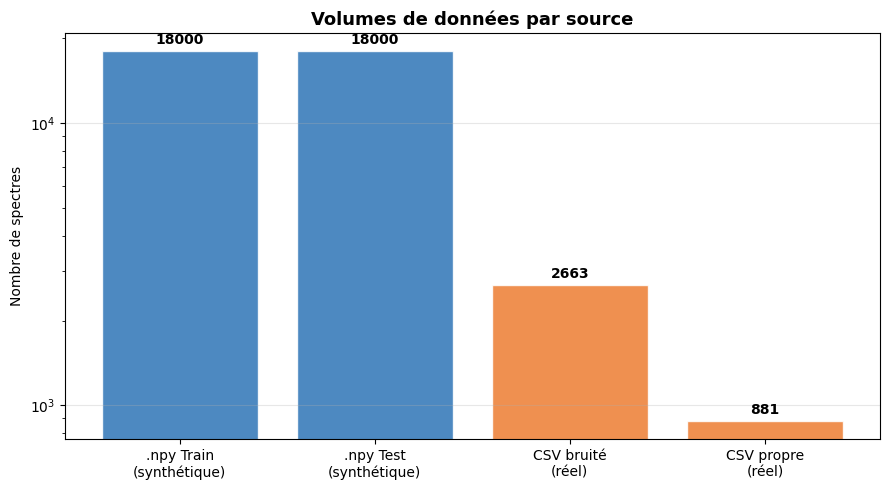

In [10]:
print('═'*70)
print('  COMPARATIF DES VOLUMES DE DONNÉES')
print('═'*70)
print(f'{"Source":25s} | {"Total":>8} | {"Train":>8} | {"Test":>8}')
print('-'*70)
print(f'{"npy (synthétique)":25s} | {npy_train_noisy.shape[0]+npy_test_noisy.shape[0]:8d} | '
      f'{npy_train_noisy.shape[0]:8d} | {npy_test_noisy.shape[0]:8d}')
print(f'{"CSV bruité (réel)":25s} | {df_csv_all.is_noisy.sum():8d} | {"—":>8} | {"—":>8}')
print(f'{"CSV propre (réel)":25s} | {(~df_csv_all.is_noisy).sum():8d} | {"—":>8} | {"—":>8}')
print('-'*70)

ratio = npy_train_noisy.shape[0] / df_csv_all.is_noisy.sum()
print(f'\n  Ratio npy_train / CSV_noisy : {ratio:.1f}x')
print(f'  → Le dataset .npy est {ratio:.0f}x plus grand que le CSV bruité')
print(f'  → Un sampler pondéré est nécessaire pour équilibrer les deux sources')
print('═'*70)

# ── Graphique comparatif ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sources = ['.npy Train\n(synthétique)', '.npy Test\n(synthétique)',
           'CSV bruité\n(réel)', 'CSV propre\n(réel)']
counts  = [npy_train_noisy.shape[0], npy_test_noisy.shape[0],
           df_csv_all.is_noisy.sum(), (~df_csv_all.is_noisy).sum()]
colors  = ['#2E75B6', '#2E75B6', '#ED7D31', '#ED7D31']
bars = ax.bar(sources, counts, color=colors, edgecolor='white', alpha=0.85)
ax.bar_label(bars, fmt='%d', padding=3, fontweight='bold')
ax.set_ylabel('Nombre de spectres')
ax.set_title('Volumes de données par source', fontweight='bold', fontsize=13)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 🎯 Section 4 — Construction des cibles de denoising CSV (proxy par classe)

Comme les CSV n'ont pas de vraie paire bruité/propre par instance, on calcule
un spectre propre **moyen par classe** — même approche que le notebook CSV seul.


In [11]:
df_csv_clean = df_csv_all[~df_csv_all['is_noisy']].reset_index(drop=True)
df_csv_noisy = df_csv_all[ df_csv_all['is_noisy']].reset_index(drop=True)

csv_clean_reference = {}
for cls_idx in range(N_CLASSES):
    subset = df_csv_clean[df_csv_clean['label_enc'] == cls_idx]['spectrum']
    if len(subset) > 0:
        csv_clean_reference[cls_idx] = np.mean(np.stack(subset.values), axis=0).astype(np.float32)

if len(df_csv_clean) > 0:
    csv_global_clean_mean = np.mean(np.stack(df_csv_clean['spectrum'].values), axis=0).astype(np.float32)
else:
    csv_global_clean_mean = np.zeros(L, dtype=np.float32)

n_with_ref = len(csv_clean_reference)
print(f'Référence propre CSV disponible pour {n_with_ref}/{N_CLASSES} classes')
if n_with_ref < N_CLASSES:
    missing = [le.classes_[c] for c in range(N_CLASSES) if c not in csv_clean_reference]
    print(f'  ⚠️ Classes sans spectre propre CSV (fallback moyenne globale) : {missing}')

Référence propre CSV disponible pour 21/30 classes
  ⚠️ Classes sans spectre propre CSV (fallback moyenne globale) : [np.str_('ABS'), np.str_('CHITOSAN'), np.str_('EVA'), np.str_('PF THERMOPLASTIC'), np.str_('PF THERMOSET'), np.str_('PHB'), np.str_('PTFE'), np.str_('PVDF'), np.str_('SAN')]


---
## 🔀 Section 5 — Split train/val et Dataset mixte

```
Train = npy_train (17100, val réservé) + CSV_noisy (80%)
Val   = npy_val (900)  +  CSV_noisy (20%)  ← suivi séparé par source
Test  = npy_test (18000, OFFICIEL)  +  CSV_noisy non vus (test réel)
```


In [12]:
# ── Split .npy : réserver un val set (comme d'habitude) ───────────────────
N_VAL_PER_CLASS_NPY = 30
val_idx_npy, train_idx_npy = [], []
for c in range(N_CLASSES):
    cls_idx = np.where(npy_labels_train == c)[0]
    rng = np.random.RandomState(SEED)
    rng.shuffle(cls_idx)
    val_idx_npy.extend(cls_idx[:N_VAL_PER_CLASS_NPY])
    train_idx_npy.extend(cls_idx[N_VAL_PER_CLASS_NPY:])
val_idx_npy   = np.array(val_idx_npy)
train_idx_npy = np.array(train_idx_npy)

X_train_npy_noisy = npy_train_noisy[train_idx_npy]
X_train_npy_clean = npy_train_clean[train_idx_npy]
y_train_npy       = npy_labels_train[train_idx_npy]

X_val_npy_noisy = npy_train_noisy[val_idx_npy]
X_val_npy_clean = npy_train_clean[val_idx_npy]
y_val_npy       = npy_labels_train[val_idx_npy]

# ── Split CSV noisy : 80% train, 20% val, garder le reste pour test réel ──
csv_noisy_counts = Counter(df_csv_noisy['label_enc'])
csv_singleton = {k for k, v in csv_noisy_counts.items() if v < 3}
df_csv_multi  = df_csv_noisy[~df_csv_noisy['label_enc'].isin(csv_singleton)]
df_csv_single = df_csv_noisy[ df_csv_noisy['label_enc'].isin(csv_singleton)]

idx_tr_csv, idx_valtest_csv = train_test_split(
    range(len(df_csv_multi)), test_size=0.3,
    random_state=SEED, stratify=df_csv_multi['label_enc'])
idx_val_csv, idx_test_csv = train_test_split(
    idx_valtest_csv, test_size=0.5, random_state=SEED)

df_csv_train = pd.concat([df_csv_multi.iloc[idx_tr_csv], df_csv_single]).reset_index(drop=True)
df_csv_val   = df_csv_multi.iloc[idx_val_csv].reset_index(drop=True)
df_csv_test  = df_csv_multi.iloc[idx_test_csv].reset_index(drop=True)

print('═'*60)
print('  RÉCAPITULATIF DU SPLIT')
print('═'*60)
print(f'  .npy  Train : {len(X_train_npy_noisy):6d}   Val : {len(X_val_npy_noisy):4d}   '
      f'Test (officiel) : {len(npy_test_noisy):6d}')
print(f'  CSV   Train : {len(df_csv_train):6d}   Val : {len(df_csv_val):4d}   '
      f'Test (réel)     : {len(df_csv_test):6d}')
print('═'*60)

════════════════════════════════════════════════════════════
  RÉCAPITULATIF DU SPLIT
════════════════════════════════════════════════════════════
  .npy  Train :  17100   Val :  900   Test (officiel) :  18000
  CSV   Train :   1864   Val :  399   Test (réel)     :    400
════════════════════════════════════════════════════════════


In [13]:
class MixedDataset(Dataset):
    """
    Combine spectres .npy (vraies paires bruité/propre) et CSV (cible proxy
    par classe). Les deux sources partagent la même grille (6700 pts).
    """
    def __init__(self, npy_noisy, npy_clean, npy_labels,
                 csv_df, csv_clean_ref, csv_global_mean):
        self.npy_noisy  = npy_noisy.astype(np.float32)
        self.npy_clean  = npy_clean.astype(np.float32)
        self.npy_labels = npy_labels.astype(np.int64)
        self.n_npy = len(npy_labels)

        self.csv_spectra = np.stack(csv_df['spectrum'].values).astype(np.float32) \
                            if len(csv_df) > 0 else np.zeros((0, len(npy_noisy[0])), np.float32)
        self.csv_labels  = csv_df['label_enc'].values.astype(np.int64) \
                            if len(csv_df) > 0 else np.zeros(0, np.int64)
        self.csv_clean_ref   = csv_clean_ref
        self.csv_global_mean = csv_global_mean
        self.n_csv = len(self.csv_labels)

    def __len__(self):
        return self.n_npy + self.n_csv

    def __getitem__(self, idx):
        if idx < self.n_npy:
            x       = torch.tensor(self.npy_noisy[idx], dtype=torch.float32)
            x_clean = torch.tensor(self.npy_clean[idx], dtype=torch.float32)
            y       = torch.tensor(self.npy_labels[idx], dtype=torch.long)
        else:
            i = idx - self.n_npy
            x = torch.tensor(self.csv_spectra[i], dtype=torch.float32)
            y = torch.tensor(self.csv_labels[i], dtype=torch.long)
            ref = self.csv_clean_ref.get(int(self.csv_labels[i]), self.csv_global_mean)
            x_clean = torch.tensor(ref, dtype=torch.float32)

        mu, sigma = x.mean(), x.std() + 1e-8
        x       = (x - mu) / sigma
        x_clean = (x_clean - mu) / sigma
        return x, x_clean, y


class SimpleMultiTaskDataset(Dataset):
    """Dataset simple pour un seul type de source (val/test séparés)."""
    def __init__(self, noisy, clean, labels):
        self.noisy  = noisy.astype(np.float32)
        self.clean  = clean.astype(np.float32)
        self.labels = labels.astype(np.int64)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        x       = torch.tensor(self.noisy[idx], dtype=torch.float32)
        x_clean = torch.tensor(self.clean[idx], dtype=torch.float32)
        y       = torch.tensor(self.labels[idx], dtype=torch.long)
        mu, sigma = x.mean(), x.std() + 1e-8
        x       = (x - mu) / sigma
        x_clean = (x_clean - mu) / sigma
        return x, x_clean, y


# ── Instanciation ──────────────────────────────────────────────────────────
train_dataset = MixedDataset(
    X_train_npy_noisy, X_train_npy_clean, y_train_npy,
    df_csv_train, csv_clean_reference, csv_global_clean_mean,
)

val_npy_dataset = SimpleMultiTaskDataset(X_val_npy_noisy, X_val_npy_clean, y_val_npy)

csv_val_spectra = np.stack(df_csv_val['spectrum'].values) if len(df_csv_val) > 0 else np.zeros((0,L))
csv_val_clean   = np.stack([
    csv_clean_reference.get(int(l), csv_global_clean_mean) for l in df_csv_val['label_enc'].values
]) if len(df_csv_val) > 0 else np.zeros((0,L))
val_csv_dataset = SimpleMultiTaskDataset(csv_val_spectra, csv_val_clean, df_csv_val['label_enc'].values)

# Test .npy officiel
test_npy_dataset = SimpleMultiTaskDataset(npy_test_noisy, npy_test_clean, npy_labels_test)

# Test CSV réel (non vu pendant l'entraînement)
csv_test_spectra = np.stack(df_csv_test['spectrum'].values) if len(df_csv_test) > 0 else np.zeros((0,L))
csv_test_clean   = np.stack([
    csv_clean_reference.get(int(l), csv_global_clean_mean) for l in df_csv_test['label_enc'].values
]) if len(df_csv_test) > 0 else np.zeros((0,L))
test_csv_dataset = SimpleMultiTaskDataset(csv_test_spectra, csv_test_clean, df_csv_test['label_enc'].values)

print(f'✓ train_dataset (mixte)     : {len(train_dataset):6d} spectres '
      f'(.npy={train_dataset.n_npy}, CSV={train_dataset.n_csv})')
print(f'✓ val_npy_dataset           : {len(val_npy_dataset):6d} spectres')
print(f'✓ val_csv_dataset           : {len(val_csv_dataset):6d} spectres')
print(f'✓ test_npy_dataset (offic.) : {len(test_npy_dataset):6d} spectres')
print(f'✓ test_csv_dataset (réel)   : {len(test_csv_dataset):6d} spectres')

✓ train_dataset (mixte)     :  18964 spectres (.npy=17100, CSV=1864)
✓ val_npy_dataset           :    900 spectres
✓ val_csv_dataset           :    399 spectres
✓ test_npy_dataset (offic.) :  18000 spectres
✓ test_csv_dataset (réel)   :    400 spectres


In [14]:
# ── DataLoaders avec sampler pondéré (équilibre npy vs CSV) ───────────────
from torch.utils.data import WeightedRandomSampler

# Poids inversement proportionnels à la taille de la source
# → chaque source a autant de chances d'être vue par epoch
npy_boost = 1.5 
weight_npy = (1.0 / train_dataset.n_npy) * npy_boost
weight_csv = 1.0 / max(train_dataset.n_csv, 1) 

sample_weights = np.concatenate([
    np.full(train_dataset.n_npy, weight_npy),
    np.full(train_dataset.n_csv, weight_csv),
])

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(train_dataset),
    replacement=True,
)

train_loader    = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                             sampler=sampler, num_workers=0, pin_memory=True)
val_npy_loader  = DataLoader(val_npy_dataset, batch_size=CFG['batch_size'],
                             shuffle=False, num_workers=0)
val_csv_loader  = DataLoader(val_csv_dataset, batch_size=CFG['batch_size'],
                             shuffle=False, num_workers=0)
test_npy_loader = DataLoader(test_npy_dataset, batch_size=CFG['batch_size'],
                             shuffle=False, num_workers=0)
test_csv_loader = DataLoader(test_csv_dataset, batch_size=CFG['batch_size'],
                             shuffle=False, num_workers=0)

xb, xb_clean, yb = next(iter(train_loader))
print(f'Train batch (mixte) : {xb.shape}')
print('✓ DataLoaders prêts — chaque batch de train contient un mélange npy/CSV')

Train batch (mixte) : torch.Size([32, 6700])
✓ DataLoaders prêts — chaque batch de train contient un mélange npy/CSV


---
## 🧠 Section 6 — Pool SSL (non supervisé, toutes sources combinées)


In [15]:
class SSLPoolDataset(Dataset):
    def __init__(self, arrays, max_n=None, seed=SEED):
        rng = np.random.RandomState(seed)
        if max_n is not None:
            n_per_array = max_n // len(arrays)
            sampled = []
            for arr in arrays:
                if len(arr) > n_per_array:
                    idx = rng.choice(len(arr), size=n_per_array, replace=False)
                    sampled.append(arr[idx].astype(np.float32))
                else:
                    sampled.append(arr.astype(np.float32))
            self.spectra = np.concatenate(sampled, axis=0)
        else:
            self.spectra = np.concatenate(arrays, axis=0).astype(np.float32)

    def __len__(self): return len(self.spectra)
    def __getitem__(self, idx):
        x = torch.tensor(self.spectra[idx], dtype=torch.float32)
        x = (x - x.mean()) / (x.std() + 1e-8)
        return x


csv_all_spectra = np.stack(df_csv_all['spectrum'].values)

ssl_dataset = SSLPoolDataset(
    arrays=[X_train_npy_noisy, X_train_npy_clean, npy_test_noisy, npy_test_clean,
            csv_all_spectra],
    max_n=35000,
)
print(f'✓ SSL pool : {len(ssl_dataset)} spectres (toutes sources mélangées)')

✓ SSL pool : 31544 spectres (toutes sources mélangées)


---
## 🏛️ Section 7 — Architecture Conformer (identique au meilleur run .npy)


In [16]:
class AttentionPooling(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn = nn.Linear(d_model, 1)
    def forward(self, z):
        w = F.softmax(self.attn(z), dim=1)
        return (w * z).sum(dim=1)


class PatchEmbedding(nn.Module):
    def __init__(self, L, patch_size, stride, d_model):
        super().__init__()
        self.P, self.S, self.D = patch_size, stride, d_model
        self.N = (L - patch_size) // stride + 2
        self.patch_proj = nn.Linear(patch_size, d_model)
        self.pos_embed  = nn.Embedding(self.N, d_model)
        self.dropout    = nn.Dropout(0.1)

    def get_raw_patches(self, x):
        B = x.shape[0]
        pad = x[:, -1:].expand(B, self.S)
        x_pad = torch.cat([x, pad], dim=1)
        return x_pad.unfold(1, self.P, self.S)

    def forward(self, x):
        patches  = self.get_raw_patches(x)
        content  = self.patch_proj(patches)
        pos_vecs = self.pos_embed(torch.arange(self.N, device=x.device))
        return self.dropout(content + pos_vecs)


class ConformerFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.W1, self.V, self.W2 = (nn.Linear(d_model, d_ff), nn.Linear(d_model, d_ff),
                                     nn.Linear(d_ff, d_model))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x = self.norm(x)
        return self.drop(self.W2(F.silu(self.W1(x)) * self.V(x)))


class ConformerConvModule(nn.Module):
    def __init__(self, d_model, kernel_size=31, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.pw1  = nn.Conv1d(d_model, 2*d_model, 1)
        self.glu  = nn.GLU(dim=1)
        self.dw   = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2, groups=d_model)
        self.bn   = nn.BatchNorm1d(d_model)
        self.act  = nn.SiLU()
        self.pw2  = nn.Conv1d(d_model, d_model, 1)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        r = x
        x = self.norm(x).transpose(1,2)
        x = self.glu(self.pw1(x))
        x = self.act(self.bn(self.dw(x)))
        x = self.drop(self.pw2(x)).transpose(1,2)
        return r + x


class ConformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, kernel_size=31):
        super().__init__()
        self.ffn1 = ConformerFFN(d_model, d_ff, dropout)
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(d_model)
        self.conv = ConformerConvModule(d_model, kernel_size, dropout)
        self.ffn2 = ConformerFFN(d_model, d_ff, dropout)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x = x + 0.5 * self.ffn1(x)
        xn = self.attn_norm(x)
        x  = x + self.drop(self.attn(xn, xn, xn)[0])
        x  = self.conv(x)
        x  = x + 0.5 * self.ffn2(x)
        return self.norm(x)


class TransformerBackbone(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            ConformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x):
        for l in self.layers: x = l(x)
        return self.norm(x)


class ReconstructionHead(nn.Module):
    def __init__(self, d_model, patch_size):
        super().__init__()
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, d_model),
                                   nn.GELU(), nn.Linear(d_model, patch_size))
    def forward(self, z): return self.head(z)


class ClassificationHead(nn.Module):
    def __init__(self, d_model, n_classes, dropout=0.1, hidden_dim=None):
        super().__init__()
        if hidden_dim is None: hidden_dim = d_model // 2
        self.attn_pool = nn.Linear(d_model, 1)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, n_classes))
    def forward(self, z):
        w = F.softmax(self.attn_pool(z), dim=1)
        return self.head((w * z).sum(dim=1))


class DenoisingHead(nn.Module):
    def __init__(self, d_model, patch_size, n_patches, stride, spectrum_length):
        super().__init__()
        self.P, self.S, self.N, self.L = patch_size, stride, n_patches, spectrum_length
        self.proj = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, d_model),
                                   nn.GELU(), nn.Linear(d_model, patch_size))
    def forward(self, z):
        B = z.shape[0]
        pr = self.proj(z)
        out = torch.zeros(B, self.L+self.S, device=z.device)
        cnt = torch.zeros(self.L+self.S, device=z.device)
        for k in range(self.N):
            s = k * self.S
            out[:, s:s+self.P] += pr[:, k, :]
            cnt[s:s+self.P]    += 1
        return (out / cnt.clamp(min=1))[:, :self.L]


print('✓ Architecture Conformer définie')

✓ Architecture Conformer définie


In [17]:
class PatchTSTSSL(nn.Module):
    """Phase 1 — Block Masking (région contiguë, meilleure config identifiée)."""
    def __init__(self, patch_embed, backbone, recon_head, mask_ratio=0.4):
        super().__init__()
        self.patch_embed = patch_embed
        self.backbone    = backbone
        self.recon_head  = recon_head
        self.mask_ratio  = mask_ratio
        self.mask_token  = nn.Parameter(torch.zeros(1, 1, patch_embed.D))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        N = self.patch_embed.N
        patches_orig = self.patch_embed.get_raw_patches(x)
        tokens = self.patch_embed(x)

        n_masked = int(N * self.mask_ratio)
        mask = torch.zeros(B, N, dtype=torch.bool, device=x.device)
        for b in range(B):
            max_start = max(1, N - n_masked)
            start = torch.randint(0, max_start, (1,), device=x.device).item()
            mask[b, start:start+n_masked] = True

        pos_vecs = self.patch_embed.pos_embed(torch.arange(N, device=x.device))
        mask_tok_pos = (self.mask_token.to(x.device) + pos_vecs.unsqueeze(0)).expand(B, -1, -1)
        tokens = torch.where(mask.unsqueeze(-1), mask_tok_pos, tokens)

        z = self.backbone(tokens)
        z_masked      = z[mask]
        patches_recon = self.recon_head(z_masked)
        patches_target= patches_orig[mask]

        loss = F.mse_loss(patches_recon, patches_target)
        return loss, mask


class PatchTSTMultiTask(nn.Module):
    def __init__(self, patch_embed, backbone, class_head, denoise_head, alpha=1.0, beta=0.5):
        super().__init__()
        self.patch_embed, self.backbone = patch_embed, backbone
        self.class_head, self.denoise_head = class_head, denoise_head
        self.alpha, self.beta = alpha, beta

    def encode(self, x):
        return self.backbone(self.patch_embed(x))

    def classify(self, x):
        return self.class_head(self.encode(x))

    def forward(self, x, y=None, clean_target=None):
        z = self.encode(x)
        logits   = self.class_head(z)
        denoised = self.denoise_head(z)
        loss = None
        if y is not None and clean_target is not None:
            loss_clf = F.cross_entropy(logits, y, label_smoothing=0.1)
            loss_den = F.mse_loss(denoised, clean_target)
            loss = self.alpha * loss_clf + self.beta * loss_den
        return logits, denoised, loss


# ── Instanciation ──────────────────────────────────────────────────────────
patch_embed  = PatchEmbedding(CFG['L'], CFG['patch_size'], CFG['stride'], CFG['d_model']).to(DEVICE)
backbone     = TransformerBackbone(CFG['d_model'], CFG['n_heads'], CFG['n_layers'],
                                    CFG['d_ff'], CFG['dropout']).to(DEVICE)
recon_head   = ReconstructionHead(CFG['d_model'], CFG['patch_size']).to(DEVICE)
class_head   = ClassificationHead(CFG['d_model'], CFG['N_CLASSES'], dropout=0.1).to(DEVICE)
denoise_head = DenoisingHead(CFG['d_model'], CFG['patch_size'], N_PATCHES,
                              CFG['stride'], CFG['L']).to(DEVICE)

total = sum(p.numel() for m in [patch_embed, backbone, class_head, denoise_head]
            for p in m.parameters() if p.requires_grad)
print(f'Total paramètres : {total:,}')

with torch.no_grad():
    xb_test = torch.randn(4, CFG['L']).to(DEVICE)
    ssl_test = PatchTSTSSL(patch_embed, backbone, recon_head).to(DEVICE)
    loss_t, _ = ssl_test(xb_test)
    print(f'Test SSL forward : loss={loss_t.item():.4f}')
    mt_test = PatchTSTMultiTask(patch_embed, backbone, class_head, denoise_head)
    lg, dn, _ = mt_test(xb_test)
    print(f'Test MultiTask   : logits={lg.shape}, denoised={dn.shape}')

Total paramètres : 6,596,191
Test SSL forward : loss=1.0144
Test MultiTask   : logits=torch.Size([4, 30]), denoised=torch.Size([4, 6700])


---
## 🛠️ Section 8 — Fonctions d'entraînement et d'évaluation


In [18]:
def ssl_train_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, n = 0.0, 0
    for x in loader:
        x = x.to(DEVICE)
        loss, _ = model(x)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * len(x); n += len(x)
    return total_loss / n

@torch.no_grad()
def ssl_eval_epoch(model, loader):
    model.eval()
    total_loss, n = 0.0, 0
    for x in loader:
        x = x.to(DEVICE)
        loss, _ = model(x)
        total_loss += loss.item() * len(x); n += len(x)
    return total_loss / n

def snr_db(clean, signal):
    noise_power  = ((signal - clean) ** 2).mean(dim=-1) + 1e-8
    signal_power = (clean ** 2).mean(dim=-1) + 1e-8
    return 10 * torch.log10(signal_power / noise_power)

def multitask_train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    total_mse, total_snr = 0.0, 0.0
    for x, x_clean, y in loader:
        x, x_clean, y = x.to(DEVICE), x_clean.to(DEVICE), y.to(DEVICE)
        logits, denoised, loss = model(x, y=y, clean_target=x_clean)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        with torch.no_grad():
            mse = F.mse_loss(denoised, x_clean)
            snr_gain = (snr_db(x_clean, denoised) - snr_db(x_clean, x)).mean()
        total_loss += loss.item()*len(y); correct += (logits.argmax(1)==y).sum().item()
        total_mse += mse.item()*len(y); total_snr += snr_gain.item()*len(y); n += len(y)
    return total_loss/n, correct/n, total_mse/n, total_snr/n

@torch.no_grad()
def multitask_eval_epoch(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    total_mse, total_snr = 0.0, 0.0
    for x, x_clean, y in loader:
        x, x_clean, y = x.to(DEVICE), x_clean.to(DEVICE), y.to(DEVICE)
        logits, denoised, loss = model(x, y=y, clean_target=x_clean)
        mse = F.mse_loss(denoised, x_clean)
        snr_gain = (snr_db(x_clean, denoised) - snr_db(x_clean, x)).mean()
        total_loss += loss.item()*len(y); correct += (logits.argmax(1)==y).sum().item()
        total_mse += mse.item()*len(y); total_snr += snr_gain.item()*len(y); n += len(y)
    return total_loss/n, correct/n, total_mse/n, total_snr/n

def plot_history(histories, title):
    fig, axes = plt.subplots(1, len(histories), figsize=(6*len(histories), 4))
    if len(histories) == 1: axes = [axes]
    for ax, (name, vals) in zip(axes, histories.items()):
        for label, curve in vals.items():
            ax.plot(curve, label=label)
        ax.set_title(name, fontweight='bold'); ax.set_xlabel('Époque')
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('✓ Fonctions définies')

✓ Fonctions définies


In [19]:
%load_ext tensorboard
# Sur Glider, lance dans un terminal séparé :
# tensorboard --logdir ~/runs/patchtst_mixed --port 6006
print(f'TensorBoard logs → {LOG_DIR}')

TensorBoard logs → /home/glider/runs/patchtst_mixed


---
## 🧠 Phase 1 — SSL Pre-training (pool mixte .npy + CSV)


=== Phase 1 : SSL Pre-training (100 époques) ===
 Époque |  Train MSE |   Val MSE |         LR
------------------------------------------------
      1 |   0.460547 |  0.225398 |   6.35e-05 <-- best
     10 |   0.034657 |  0.045014 |   1.00e-03
     20 |   0.010528 |  0.008961 |   9.70e-04 <-- best
     30 |   0.014230 |  0.010536 |   8.83e-04
     40 |   0.014059 |  0.010625 |   7.50e-04
     50 |   0.005187 |  0.005316 |   5.87e-04
     60 |   0.004127 |  0.003940 |   4.13e-04
     70 |   0.003222 |  0.003018 |   2.50e-04 <-- best
     80 |   0.002650 |  0.002607 |   1.17e-04 <-- best
     90 |   0.002385 |  0.002228 |   3.01e-05 <-- best
    100 |   0.002300 |  0.002159 |   4.00e-09


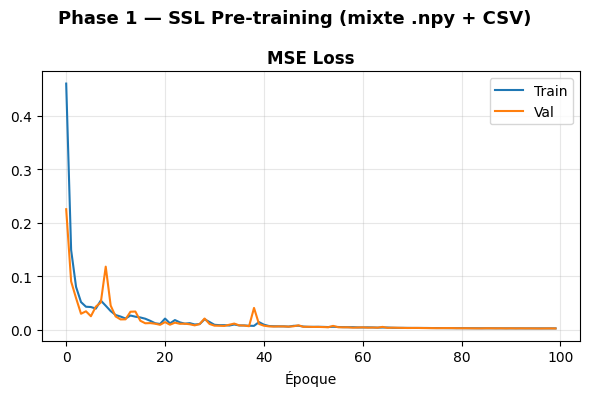


✓ Meilleure val MSE : 0.002125
✓ Backbone sauvegardé → /home/glider/models/ssl_backbone_mixed.pth


In [20]:
ssl_model = PatchTSTSSL(patch_embed, backbone, recon_head, CFG['mask_ratio']).to(DEVICE)
patch_embed.dropout.p = 0.0

n_ssl = len(ssl_dataset)
n_val_ssl = int(0.2 * n_ssl)
ssl_train_sub, ssl_val_sub = torch.utils.data.random_split(
    ssl_dataset, [n_ssl-n_val_ssl, n_val_ssl],
    generator=torch.Generator().manual_seed(SEED))
ssl_train_loader = DataLoader(ssl_train_sub, batch_size=CFG['ssl_batch'], shuffle=True, num_workers=0)
ssl_val_loader   = DataLoader(ssl_val_sub, batch_size=CFG['ssl_batch'], shuffle=False, num_workers=0)

ssl_optimizer = AdamW(ssl_model.parameters(), lr=CFG['ssl_lr'], weight_decay=1e-4)
ssl_scheduler = OneCycleLR(ssl_optimizer, max_lr=CFG['ssl_lr'], epochs=CFG['ssl_epochs'],
                           steps_per_epoch=len(ssl_train_loader),
                           pct_start=0.1, div_factor=25.0, final_div_factor=1e4)

ssl_history = {'train': [], 'val': []}
best_ssl_loss = float('inf')

print(f'=== Phase 1 : SSL Pre-training ({CFG["ssl_epochs"]} époques) ===')
print(f'{"Époque":>7} | {"Train MSE":>10} | {"Val MSE":>9} | {"LR":>10}')
print('-'*48)

for epoch in range(1, CFG['ssl_epochs']+1):
    tr = ssl_train_epoch(ssl_model, ssl_train_loader, ssl_optimizer, ssl_scheduler)
    va = ssl_eval_epoch(ssl_model, ssl_val_loader)
    ssl_history['train'].append(tr); ssl_history['val'].append(va)
    safe_log(writer, 'Phase1_SSL/Loss', {'Train': tr, 'Val': va}, epoch, method='add_scalars')
    if va < best_ssl_loss:
        best_ssl_loss = va
        flag = ' <-- best'
    else: flag = ''
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:7d} | {tr:10.6f} | {va:9.6f} | {ssl_optimizer.param_groups[0]["lr"]:10.2e}{flag}')

patch_embed.dropout.p = 0.1
plot_history({'MSE Loss': {'Train': ssl_history['train'], 'Val': ssl_history['val']}},
             'Phase 1 — SSL Pre-training (mixte .npy + CSV)')
print(f'\n✓ Meilleure val MSE : {best_ssl_loss:.6f}')

torch.save({'patch_embed': patch_embed.state_dict(), 'backbone': backbone.state_dict(),
            'cfg': CFG, 'ssl_val_loss': best_ssl_loss}, CFG['ssl_path'])
print(f'✓ Backbone sauvegardé → {CFG["ssl_path"]}')

---
## 🔍 Phase 2 — Linear Probing (train mixte, val séparé npy/CSV)


✓ Poids SSL chargés (val MSE = 0.002125)
=== Phase 2 : Linear Probing (80 époques) ===
 Époque |  Tr.Acc |  Val npy |  Val CSV |  SNR npy |  SNR CSV
----------------------------------------------------------------------


      1 | 34.16% |  28.00% |  88.72% |   +3.54dB |   +5.52dB ★
      2 | 51.21% |  38.44% |  91.48% |   +4.19dB |   +5.55dB ★
      3 | 56.63% |  50.22% |  93.98% |   +4.72dB |   +6.69dB ★
      4 | 59.56% |  54.67% |  94.99% |   +4.88dB |   +6.00dB ★
      5 | 62.15% |  59.89% |  95.74% |   +5.04dB |   +7.37dB ★
      6 | 65.21% |  63.56% |  95.24% |   +5.09dB |   +8.42dB ★
      7 | 65.92% |  66.89% |  94.74% |   +5.36dB |   +7.71dB ★
      8 | 68.02% |  69.00% |  95.49% |   +5.37dB |   +8.57dB ★
      9 | 69.08% |  70.00% |  96.49% |   +5.46dB |   +8.74dB ★
     10 | 70.53% |  73.22% |  96.74% |   +5.55dB |   +8.47dB ★
     11 | 70.28% |  72.89% |  94.74% |   +5.75dB |   +8.66dB
     12 | 70.90% |  72.00% |  95.74% |   +5.86dB |   +8.89dB
     13 | 72.07% |  77.33% |  95.24% |   +5.67dB |   +8.69dB ★
     14 | 72.28% |  75.33% |  96.74% |   +5.88dB |   +9.30dB
     15 | 72.29% |  76.22% |  96.74% |   +5.76dB |   +9.35dB ★
     16 | 73.85% |  79.22% |  96.24% |   +5.97dB |   +8.97dB 

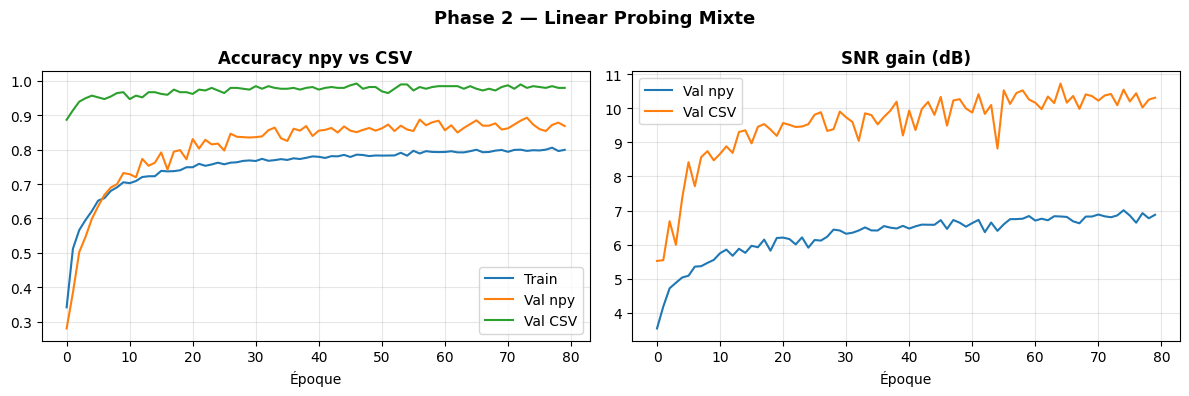

In [21]:
checkpoint = torch.load(CFG['ssl_path'], map_location=DEVICE, weights_only=False)
patch_embed.load_state_dict(checkpoint['patch_embed'])
backbone.load_state_dict(checkpoint['backbone'])
print(f'✓ Poids SSL chargés (val MSE = {checkpoint["ssl_val_loss"]:.6f})')

class_head   = ClassificationHead(CFG['d_model'], CFG['N_CLASSES'], dropout=0.1).to(DEVICE)
denoise_head = DenoisingHead(CFG['d_model'], CFG['patch_size'], N_PATCHES,
                              CFG['stride'], CFG['L']).to(DEVICE)

for p in patch_embed.parameters(): p.requires_grad = False
for p in backbone.parameters():    p.requires_grad = False

probe_model = PatchTSTMultiTask(patch_embed, backbone, class_head, denoise_head,
                                 alpha=CFG['alpha'], beta=CFG['beta']).to(DEVICE)
probe_optimizer = AdamW(filter(lambda p: p.requires_grad, probe_model.parameters()),
                        lr=CFG['probe_lr'], weight_decay=1e-4)

probe_history = {'train_acc':[], 'val_npy_acc':[], 'val_csv_acc':[],
                  'train_snr':[], 'val_npy_snr':[], 'val_csv_snr':[]}
best_probe_acc = 0.0   # basé sur la MOYENNE npy+csv pour équilibrer les deux

print(f'=== Phase 2 : Linear Probing ({CFG["probe_epochs"]} époques) ===')
print(f'{"Époque":>7} | {"Tr.Acc":>7} | {"Val npy":>8} | {"Val CSV":>8} | {"SNR npy":>8} | {"SNR CSV":>8}')
print('-'*70)

for epoch in range(1, CFG['probe_epochs']+1):
    tr_loss, tr_acc, tr_mse, tr_snr = multitask_train_epoch(probe_model, train_loader, probe_optimizer)
    _, va_npy_acc, _, va_npy_snr = multitask_eval_epoch(probe_model, val_npy_loader)
    _, va_csv_acc, _, va_csv_snr = multitask_eval_epoch(probe_model, val_csv_loader)

    for k, v in zip(['train_acc','val_npy_acc','val_csv_acc','train_snr','val_npy_snr','val_csv_snr'],
                     [tr_acc, va_npy_acc, va_csv_acc, tr_snr, va_npy_snr, va_csv_snr]):
        probe_history[k].append(v)

    safe_log(writer, 'Phase2_Probe/Acc_npy', {'Train': tr_acc, 'Val': va_npy_acc}, epoch, method='add_scalars')
    safe_log(writer, 'Phase2_Probe/Acc_csv', {'Val': va_csv_acc}, epoch, method='add_scalars')

    avg_acc = (va_npy_acc + va_csv_acc) / 2
    if avg_acc > best_probe_acc:
        best_probe_acc = avg_acc
        torch.save(probe_model.state_dict(), CFG['probe_path'])
        flag = ' ★'
    else: flag = ''

    print(f'{epoch:7d} | {tr_acc:6.2%} | {va_npy_acc:7.2%} | {va_csv_acc:7.2%} | '
          f'{va_npy_snr:+7.2f}dB | {va_csv_snr:+7.2f}dB{flag}')

print(f'\n✓ Meilleure moyenne (npy+CSV)/2 : {best_probe_acc:.2%}')

plot_history({
    'Accuracy npy vs CSV': {'Train': probe_history['train_acc'],
                            'Val npy': probe_history['val_npy_acc'],
                            'Val CSV': probe_history['val_csv_acc']},
    'SNR gain (dB)'      : {'Val npy': probe_history['val_npy_snr'],
                            'Val CSV': probe_history['val_csv_snr']},
}, 'Phase 2 — Linear Probing Mixte')

---
## 🎯 Phase 3 — Fine-tuning complet (train mixte, val séparé)


In [22]:
probe_model.load_state_dict(torch.load(CFG['probe_path'], map_location=DEVICE, weights_only=False))
print(f'✓ Poids Phase 2 chargés')

for p in probe_model.parameters(): p.requires_grad = True

ft_optimizer = AdamW([
    {'params': probe_model.patch_embed.parameters(),  'lr': CFG['ft_lr']},
    {'params': probe_model.backbone.parameters(),     'lr': CFG['ft_lr']},
    {'params': probe_model.class_head.parameters(),   'lr': CFG['ft_lr']*10},
    {'params': probe_model.denoise_head.parameters(), 'lr': CFG['ft_lr']*10},
], weight_decay=1e-4)
ft_scheduler = CosineAnnealingLR(ft_optimizer, T_max=CFG['ft_epochs'], eta_min=1e-6)

print(f'  LR backbone : {CFG["ft_lr"]:.0e}   LR têtes : {CFG["ft_lr"]*10:.0e}')

✓ Poids Phase 2 chargés
  LR backbone : 1e-05   LR têtes : 1e-04


=== Phase 3 : Fine-tuning (80 époques) ===
 Époque |  Tr.Acc |  Val npy |  Val CSV |  SNR npy |  SNR CSV
----------------------------------------------------------------------


      1 | 82.12% |  90.11% |  98.75% |   +7.20dB |  +10.90dB ★
      5 | 86.52% |  91.00% |  99.50% |   +7.55dB |  +11.02dB
     10 | 89.27% |  93.11% |  99.50% |   +7.92dB |  +10.90dB ★
     15 | 90.96% |  93.22% |  99.25% |   +8.16dB |  +10.96dB
     20 | 91.68% |  94.33% |  99.25% |   +8.46dB |  +11.07dB
     25 | 92.93% |  95.11% |  99.50% |   +8.62dB |  +11.08dB ★
     30 | 93.42% |  95.22% |  99.50% |   +8.83dB |  +11.10dB ★
     35 | 94.00% |  94.89% |  99.50% |   +9.01dB |  +11.21dB
     40 | 94.19% |  95.56% |  99.50% |   +9.15dB |  +11.34dB ★
     45 | 94.57% |  96.22% |  99.25% |   +9.26dB |  +11.38dB ★
     50 | 94.77% |  96.22% |  99.50% |   +9.37dB |  +11.48dB ★
     55 | 94.92% |  96.44% |  99.50% |   +9.46dB |  +11.50dB ★
     60 | 94.99% |  96.44% |  99.50% |   +9.52dB |  +11.53dB
     65 | 95.27% |  96.22% |  99.50% |   +9.56dB |  +11.57dB
     70 | 95.41% |  96.11% |  99.50% |   +9.59dB |  +11.51dB
     75 | 95.29% |  96.22% |  99.50% |   +9.61dB |  +11.61dB
     80 

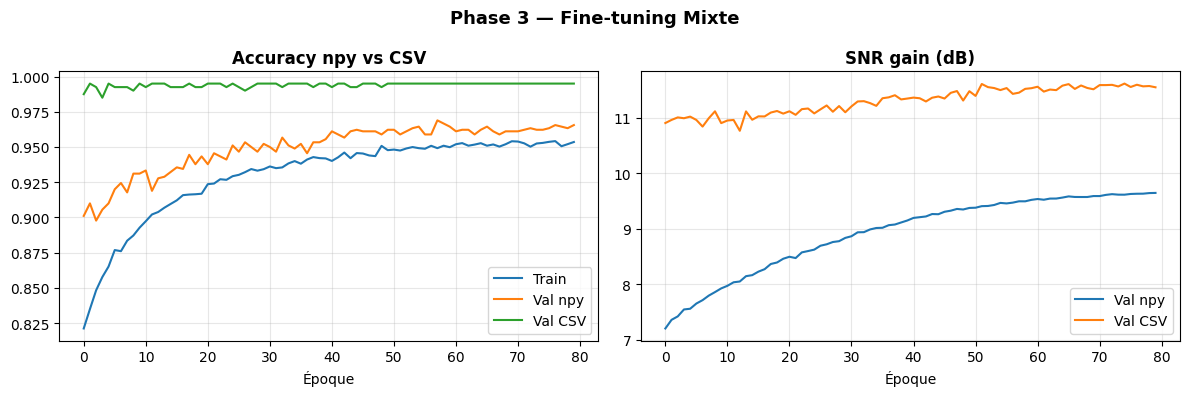

In [23]:
ft_history = {'train_acc':[], 'val_npy_acc':[], 'val_csv_acc':[],
              'train_snr':[], 'val_npy_snr':[], 'val_csv_snr':[]}
best_ft_acc = 0.0

print(f'=== Phase 3 : Fine-tuning ({CFG["ft_epochs"]} époques) ===')
print(f'{"Époque":>7} | {"Tr.Acc":>7} | {"Val npy":>8} | {"Val CSV":>8} | {"SNR npy":>8} | {"SNR CSV":>8}')
print('-'*70)

for epoch in range(1, CFG['ft_epochs']+1):
    tr_loss, tr_acc, tr_mse, tr_snr = multitask_train_epoch(probe_model, train_loader, ft_optimizer)
    _, va_npy_acc, _, va_npy_snr = multitask_eval_epoch(probe_model, val_npy_loader)
    _, va_csv_acc, _, va_csv_snr = multitask_eval_epoch(probe_model, val_csv_loader)
    ft_scheduler.step()

    for k, v in zip(['train_acc','val_npy_acc','val_csv_acc','train_snr','val_npy_snr','val_csv_snr'],
                     [tr_acc, va_npy_acc, va_csv_acc, tr_snr, va_npy_snr, va_csv_snr]):
        ft_history[k].append(v)

    safe_log(writer, 'Phase3_FT/Acc_npy', {'Train': tr_acc, 'Val': va_npy_acc}, epoch, method='add_scalars')
    safe_log(writer, 'Phase3_FT/Acc_csv', {'Val': va_csv_acc}, epoch, method='add_scalars')

    if epoch % 5 == 0:
        torch.save({
            'model_state': probe_model.state_dict(), 'optimizer': ft_optimizer.state_dict(),
            'scheduler': ft_scheduler.state_dict(), 'epoch': epoch,
            'ft_history': ft_history, 'best_ft_acc': best_ft_acc, 'cfg': CFG,
        }, os.path.join(HOME, 'models', 'checkpoint_mixed_latest.pth'))

    avg_acc = (va_npy_acc + va_csv_acc) / 2
    if avg_acc > best_ft_acc:
        best_ft_acc = avg_acc
        torch.save({'model_state': probe_model.state_dict(), 'cfg': CFG,
                    'le_classes': le.classes_, 'val_acc': best_ft_acc}, CFG['final_path'])
        flag = ' ★'
    else: flag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:7d} | {tr_acc:6.2%} | {va_npy_acc:7.2%} | {va_csv_acc:7.2%} | '
              f'{va_npy_snr:+7.2f}dB | {va_csv_snr:+7.2f}dB{flag}')

writer.flush()
print(f'\n✓ Meilleure moyenne (npy+CSV)/2 : {best_ft_acc:.2%}')
print(f'  Sauvegardé → {CFG["final_path"]}')

plot_history({
    'Accuracy npy vs CSV': {'Train': ft_history['train_acc'],
                            'Val npy': ft_history['val_npy_acc'],
                            'Val CSV': ft_history['val_csv_acc']},
    'SNR gain (dB)'      : {'Val npy': ft_history['val_npy_snr'],
                            'Val CSV': ft_history['val_csv_snr']},
}, 'Phase 3 — Fine-tuning Mixte')

---
## 📊 Évaluation finale — SUR LES DEUX TEST SETS SÉPARÉMENT

C'est le test décisif : le modèle mixte doit performer sur **les deux domaines**,
contrairement au modèle .npy seul qui s'effondrait à 23.47% sur le CSV réel.


In [24]:
ckpt = torch.load(CFG['final_path'], map_location=DEVICE, weights_only=False)
probe_model.load_state_dict(ckpt['model_state'])
probe_model.eval()

def evaluate_full(model, loader):
    all_preds, all_labels = [], []
    all_snr_before, all_snr_after = [], []
    with torch.no_grad():
        for x, x_clean, y in loader:
            x, x_clean = x.to(DEVICE), x_clean.to(DEVICE)
            logits, denoised, _ = model(x)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
            all_snr_before.append(snr_db(x_clean, x).cpu().numpy())
            all_snr_after.append(snr_db(x_clean, denoised).cpu().numpy())
    return (np.array(all_preds), np.array(all_labels),
            np.concatenate(all_snr_before), np.concatenate(all_snr_after))

# ── Test .npy officiel ──────────────────────────────────────────────────
preds_npy, labels_npy, snr_b_npy, snr_a_npy = evaluate_full(probe_model, test_npy_loader)
acc_npy = accuracy_score(labels_npy, preds_npy)

# ── Test CSV réel ────────────────────────────────────────────────────────
preds_csv, labels_csv, snr_b_csv, snr_a_csv = evaluate_full(probe_model, test_csv_loader)
acc_csv = accuracy_score(labels_csv, preds_csv)

print('═'*65)
print('  ÉVALUATION FINALE — MODÈLE MIXTE')
print('═'*65)
print(f'  Test .npy (synthétique, officiel) : {acc_npy:.2%}   SNR : {(snr_a_npy-snr_b_npy).mean():+.2f}dB')
print(f'  Test CSV (réel, jamais vu)         : {acc_csv:.2%}   SNR : {(snr_a_csv-snr_b_csv).mean():+.2f}dB')
print('═'*65)
print()
print('  Comparaison avec le modèle .npy SEUL :')
print(f'    .npy seul → test .npy : 95.25%')
print(f'    .npy seul → test CSV  : 23.47%  ⚠️ domain gap massif')
print(f'    Mixte     → test .npy : {acc_npy:.2%}')
print(f'    Mixte     → test CSV  : {acc_csv:.2%}')

═════════════════════════════════════════════════════════════════
  ÉVALUATION FINALE — MODÈLE MIXTE
═════════════════════════════════════════════════════════════════
  Test .npy (synthétique, officiel) : 94.72%   SNR : +9.37dB
  Test CSV (réel, jamais vu)         : 99.00%   SNR : +11.49dB
═════════════════════════════════════════════════════════════════

  Comparaison avec le modèle .npy SEUL :
    .npy seul → test .npy : 95.25%
    .npy seul → test CSV  : 23.47%  ⚠️ domain gap massif
    Mixte     → test .npy : 94.72%
    Mixte     → test CSV  : 99.00%


In [25]:
print('=== Rapport de classification — Test .npy ===')
print(classification_report(labels_npy, preds_npy, target_names=le.classes_, zero_division=0))

=== Rapport de classification — Test .npy ===
                  precision    recall  f1-score   support

             ABS       0.83      0.89      0.86       600
         ACRYLIC       0.61      0.56      0.58       600
       CELLULOSE       0.95      0.98      0.97       600
        CHITOSAN       0.97      0.95      0.96       600
             ENR       0.99      1.00      0.99       600
            EPDM       0.95      0.93      0.94       600
             EVA       0.98      0.98      0.98       600
            HDPE       0.88      0.94      0.91       600
            LDPE       0.89      0.84      0.86       600
           NYLON       0.99      0.99      0.99       600
            PBAT       1.00      1.00      1.00       600
             PBS       1.00      1.00      1.00       600
              PC       1.00      0.99      0.99       600
            PEEK       1.00      1.00      1.00       600
             PEI       1.00      0.99      1.00       600
             PET       1.

In [26]:
print('=== Rapport de classification — Test CSV réel ===')
classes_present_csv = sorted(set(labels_csv))
names_csv = [le.classes_[i] for i in classes_present_csv]
print(classification_report(labels_csv, preds_csv, labels=classes_present_csv,
                             target_names=names_csv, zero_division=0))

=== Rapport de classification — Test CSV réel ===
                  precision    recall  f1-score   support

             ABS       1.00      1.00      1.00        21
         ACRYLIC       1.00      0.91      0.95        11
       CELLULOSE       1.00      1.00      1.00        11
        CHITOSAN       1.00      1.00      1.00        19
             ENR       1.00      1.00      1.00        13
            EPDM       1.00      1.00      1.00        11
             EVA       1.00      0.95      0.97        19
            HDPE       1.00      1.00      1.00         9
            LDPE       1.00      1.00      1.00        10
           NYLON       1.00      1.00      1.00         9
            PBAT       1.00      1.00      1.00        10
             PBS       1.00      0.83      0.91        12
              PC       1.00      1.00      1.00        11
            PEEK       1.00      1.00      1.00        10
             PEI       1.00      1.00      1.00        10
             PET     

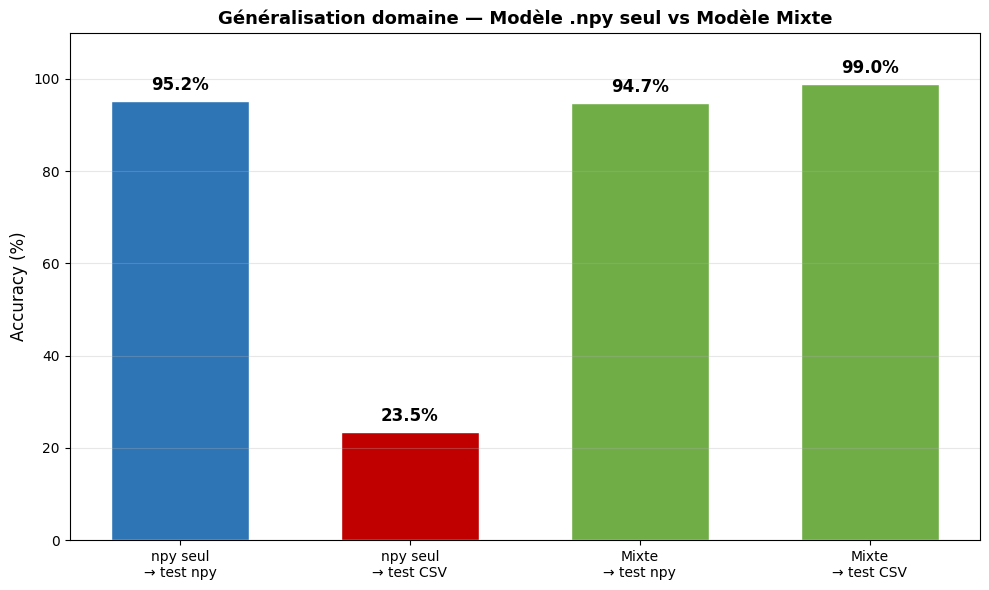

In [27]:
# ── Graphique comparatif final ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
labels_plot = ['npy seul\n→ test npy', 'npy seul\n→ test CSV',
               'Mixte\n→ test npy', 'Mixte\n→ test CSV']
values_plot = [0.9525, 0.2347, acc_npy, acc_csv]
colors_plot = ['#2E75B6', '#C00000', '#70AD47', '#70AD47']

bars = ax.bar(labels_plot, [v*100 for v in values_plot], color=colors_plot,
              edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Généralisation domaine — Modèle .npy seul vs Modèle Mixte',
             fontweight='bold', fontsize=13)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(HOME, 'comparison_mixed_model.png'), dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(f'Taille du CSV test : {len(df_csv_test)}')
print(f'Distribution par classe :')
print(df_csv_test['label'].value_counts())

Taille du CSV test : 400
Distribution par classe :
label
PF THERMOPLASTIC    23
PVDF                23
PHB                 22
PF THERMOSET        21
ABS                 21
EVA                 19
CHITOSAN            19
PS                  16
PVA                 14
PU                  13
ENR                 13
PET                 13
SAN                 13
PBS                 12
ACRYLIC             11
EPDM                11
PC                  11
PLA                 11
CELLULOSE           11
PVC                 11
LDPE                10
PBAT                10
PEI                 10
PTFE                10
PEEK                10
NYLON                9
HDPE                 9
PMMA                 9
POM                  8
PP                   7
Name: count, dtype: int64


In [29]:
# ── Logger ce run dans le dashboard HParams comparatif ────────────────────
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

HPARAMS_DASHBOARD_MIXED = os.path.join(HOME, 'runs', 'hparams_dashboard_mixed')

def log_run_to_dashboard(cfg, metrics, run_label=None, dashboard_dir=HPARAMS_DASHBOARD_MIXED):
    if run_label is None:
        run_label = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_dir = os.path.join(dashboard_dir, run_label)
    run_writer = SummaryWriter(run_dir)
    hparams_clean = {k: v for k, v in cfg.items() if isinstance(v, (int, float, str, bool))}
    run_writer.add_hparams(hparams_clean, metrics)
    run_writer.close()
    print(f'✓ Run "{run_label}" loggé dans le dashboard')


log_run_to_dashboard(
    cfg={
        'dataset'    : 'mixed_npy_csv',
        'patch_size' : CFG['patch_size'],
        'stride'     : CFG['stride'],
        'n_layers'   : CFG['n_layers'],
        'd_model'    : CFG['d_model'],
        'n_heads'    : CFG['n_heads'],
        'beta'       : CFG['beta'],
    },
    metrics={
        'test_npy_acc' : acc_npy,
        'test_csv_acc' : acc_csv,
        'avg_acc'      : (acc_npy + acc_csv) / 2,
    },
    run_label='mixed_beta03_baseline'   # ← change ce label à chaque run
)

✓ Run "mixed_beta03_baseline" loggé dans le dashboard
